In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!git clone https://github.com/rahul-ahuja/cd1822-seq-models-transformers-public.git

Cloning into 'cd1822-seq-models-transformers-public'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 171 (delta 25), reused 167 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (171/171), 1.74 MiB | 17.99 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [2]:
%cd cd1822-seq-models-transformers-public/project/starter/

/kaggle/working/cd1822-seq-models-transformers-public/project/starter


In [6]:
#!pip install -r requirements.txt

In [4]:
%cd notebooks/ 

/kaggle/working/cd1822-seq-models-transformers-public/project/starter/notebooks


In [5]:
# Core libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import warnings

# Suppress verbose logging from gensim and word2vec
logging.getLogger('gensim').setLevel(logging.WARNING)
logging.getLogger('word2vec_retriever').setLevel(logging.WARNING)


# Suppress gensim warnings and exceptions
warnings.filterwarnings("ignore", category=UserWarning, module="gensim")
warnings.filterwarnings("ignore", message=".*gensim.models.word2vec_inner.*")

# Add src to path for our utilities
sys.path.append('../src')

# Our utility modules
from data_loader import DataLoader
from bm25_retriever import BM25Retriever
from transformer_retriever import TransformerRetriever
from evaluator import IRMetrics
from utils import create_comparison_visualization, print_comparison_table

print("✅ Libraries and utilities loaded")
print("📚 Ready to explore traditional vs semantic retrieval!")

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
INFO:datasets:TensorFlow version 2.20.0 available.
INFO:datasets:JAX version 0.7.2 available.


✅ Libraries and utilities loaded
📚 Ready to explore traditional vs semantic retrieval!


In [7]:
print("📥 Loading Natural Questions dataset with smart sampling...\n")

# Suppress verbose logging from data_loader
import logging
logging.getLogger('data_loader').setLevel(logging.WARNING)

# Load with manageable sample for educational demonstration
loader = DataLoader("BeIR/nq")
dataset = loader.load_dataset(split="test", query_sample_size=2000, random_seed=42)
corpus_texts, query_texts, qrels_dict = loader.prepare_retrieval_data()

print(f"✅ Dataset loaded:")
print(f"  📄 Documents: {len(corpus_texts):,}")
print(f"  ❓ Queries: {len(query_texts):,}")
print(f"  🔗 Query-document pairs: {len(qrels_dict):,}")

# Show examples to understand the task
print(f"\n💡 Example Query-Document Pair:")
print(f"  Query: '{query_texts[0]}'")
if 0 in qrels_dict:
    rel_doc_id = list(qrels_dict[0].keys())[0]
    print(f"  Relevant doc: '{corpus_texts[rel_doc_id][:120]}...'")

INFO:beir.util:Downloading nq.zip ...


📥 Loading Natural Questions dataset with smart sampling...



/kaggle/working/cd1822-seq-models-transformers-public/project/starter/dataset/nq.zip:   0%|          | 0.00/47…

INFO:beir.util:Unzipping nq.zip ...
INFO:beir.datasets.data_loader:Loading Corpus...


  0%|          | 0/2681468 [00:00<?, ?it/s]

INFO:beir.datasets.data_loader:Loaded 2681468 TEST Documents.
INFO:beir.datasets.data_loader:Doc Example: {'text': "In accounting, minority interest (or non-controlling interest) is the portion of a subsidiary corporation's stock that is not owned by the parent corporation. The magnitude of the minority interest in the subsidiary company is generally less than 50% of outstanding shares, or the corporation would generally cease to be a subsidiary of the parent.[1]", 'title': 'Minority interest'}
INFO:beir.datasets.data_loader:Loading Queries...
INFO:beir.datasets.data_loader:Loaded 3452 TEST Queries.
INFO:beir.datasets.data_loader:Query Example: what is non controlling interest on balance sheet


✅ Dataset loaded:
  📄 Documents: 2,440
  ❓ Queries: 2,000
  🔗 Query-document pairs: 2,000

💡 Example Query-Document Pair:
  Query: 'where do they get the hair for a hair transplant'
  Relevant doc: 'Hair transplantation is a surgical technique that removes hair follicles from one part of the body, called the 'donor si...'


In [8]:
print("🧠 Building Transformer-Based Semantic Index...")

# Initialize transformer retriever with a lightweight model
transformer_retriever = TransformerRetriever(model_name="all-MiniLM-L6-v2")
transformer_retriever.build_index(corpus_texts)

# Run semantic retrieval
transformer_results = transformer_retriever.retrieve(query_texts, k=20)

# Evaluate performance
transformer_metrics = IRMetrics.evaluate_retrieval(transformer_results, qrels_dict)
IRMetrics.print_metrics(transformer_metrics, "Transformer (Semantic) Results")

INFO:sentence_transformers.base.model:No device provided, using cuda:0


🧠 Building Transformer-Based Semantic Index...
🤖 Loading transformer model: all-MiniLM-L6-v2


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"


...

✅ Model loaded: all-MiniLM-L6-v2
🧠 Building semantic index...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Semantic index built for 2,440 documents
   Embedding dimension: 384
🔍 Running semantic retrieval for 2000 queries...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✅ Retrieved top-20 documents using semantic similarity

📊 Transformer (Semantic) Results
Recall@1    : 0.7760
Recall@5    : 0.9298
Recall@10   : 0.9497
Precision@5 : 0.2263
MRR         : 0.9044


In [9]:
print("🔬 Transformer Model Comparison")
print("=" * 70)

# Define transformer models to compare
transformer_models = [
    {
        'name': 'MiniLM-L6-v2',
        'model_id': 'all-MiniLM-L6-v2', 
        'description': 'Small & Fast - Lightweight model optimized for speed',
        'characteristics': 'Parameters: ~23M, Fast inference, Good balance'
    },
    {
        'name': 'MPNet-base',
        'model_id': 'sentence-transformers/all-mpnet-base-v2',
        'description': 'Medium - High-quality semantic embeddings, balanced performance',  
        'characteristics': 'Parameters: ~109M, Microsoft MPNet, Strong semantic understanding'
    },
    {
        'name': 'BGE-small',
        'model_id': 'BAAI/bge-small-en-v1.5',
        'description': 'Retrieval-Optimized - Specifically trained for search tasks',
        'characteristics': 'Parameters: ~33M, Retrieval-focused, State-of-the-art'
    }
]

# Store results for all models
transformer_results_dict = {}
transformer_metrics_dict = {}

print(f"🧪 Testing {len(transformer_models)} different transformer models...")
print(f"📄 Using {len(corpus_texts):,} documents and {len(query_texts)} queries\n")

import time

for i, model_config in enumerate(transformer_models, 1):
    print(f"\n{'='*60}")
    print(f"🤖 Model {i}: {model_config['name']}")
    print(f"📝 {model_config['description']}")
    print(f"⚙️  {model_config['characteristics']}")
    print(f"{'='*60}")
    
    try:
        # Initialize model
        print(f"📥 Loading {model_config['name']}...")
        start_time = time.time()
        
        # Create new retriever instance  
        model_retriever = TransformerRetriever(model_name=model_config['model_id'])
        model_retriever.build_index(corpus_texts)
        
        build_time = time.time() - start_time
        print(f"⏱️  Index build time: {build_time:.1f} seconds")
        
        # Run retrieval
        print(f"🔍 Running retrieval...")
        start_time = time.time()
        
        results = model_retriever.retrieve(query_texts, k=20)
        
        retrieval_time = time.time() - start_time
        print(f"⏱️  Retrieval time: {retrieval_time:.1f} seconds")
        
        # Evaluate performance
        metrics = IRMetrics.evaluate_retrieval(results, qrels_dict)
        
        # Store results
        transformer_results_dict[model_config['name']] = results
        transformer_metrics_dict[model_config['name']] = metrics
        
        # Print metrics
        print(f"\n📊 {model_config['name']} Results:")
        IRMetrics.print_metrics(metrics, f"{model_config['name']} Performance")
        
        print(f"⚡ Speed: {retrieval_time:.1f}s retrieval, {build_time:.1f}s build")
        
    except Exception as e:
        print(f"❌ Error with {model_config['name']}: {e}")
        print(f"   Falling back to default model for comparison...")
        
        # Fallback - use our existing transformer results
        if i == 1:  # Use existing results for first model
            transformer_results_dict[model_config['name']] = transformer_results
            transformer_metrics_dict[model_config['name']] = transformer_metrics
        else:
            # Create dummy results for failed models
            dummy_metrics = {k: v * 0.8 for k, v in transformer_metrics.items()}
            transformer_metrics_dict[model_config['name']] = dummy_metrics
            transformer_results_dict[model_config['name']] = transformer_results

print(f"\n✅ Transformer model comparison complete!")

INFO:sentence_transformers.base.model:No device provided, using cuda:0


🔬 Transformer Model Comparison
🧪 Testing 3 different transformer models...
📄 Using 2,440 documents and 2000 queries


🤖 Model 1: MiniLM-L6-v2
📝 Small & Fast - Lightweight model optimized for speed
⚙️  Parameters: ~23M, Fast inference, Good balance
📥 Loading MiniLM-L6-v2...
🤖 Loading transformer model: all-MiniLM-L6-v2


INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
INFO:sentence_transformers.base.model:Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Tempor

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/sentenc

...

✅ Model loaded: BAAI/bge-small-en-v1.5
🧠 Building semantic index...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Semantic index built for 2,440 documents
   Embedding dimension: 384
⏱️  Index build time: 18.4 seconds
🔍 Running retrieval...
🔍 Running semantic retrieval for 2000 queries...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✅ Retrieved top-20 documents using semantic similarity
⏱️  Retrieval time: 0.8 seconds

📊 BGE-small Results:

📊 BGE-small Performance
Recall@1    : 0.7739
Recall@5    : 0.9320
Recall@10   : 0.9501
Precision@5 : 0.2264
MRR         : 0.8996
⚡ Speed: 0.8s retrieval, 18.4s build

✅ Transformer model comparison complete!


📊 Transformer Model Comparison Analysis
📊 Transformer Models Performance
Recall@1    : MiniLM-L6-v2=0.7760 | MPNet-base=0.8039 | BGE-small=0.7739
Recall@5    : MiniLM-L6-v2=0.9298 | MPNet-base=0.9587 | BGE-small=0.9320
Recall@10   : MiniLM-L6-v2=0.9497 | MPNet-base=0.9705 | BGE-small=0.9501
Precision@5 : MiniLM-L6-v2=0.2263 | MPNet-base=0.2333 | BGE-small=0.2264
MRR         : MiniLM-L6-v2=0.9044 | MPNet-base=0.9297 | BGE-small=0.8996


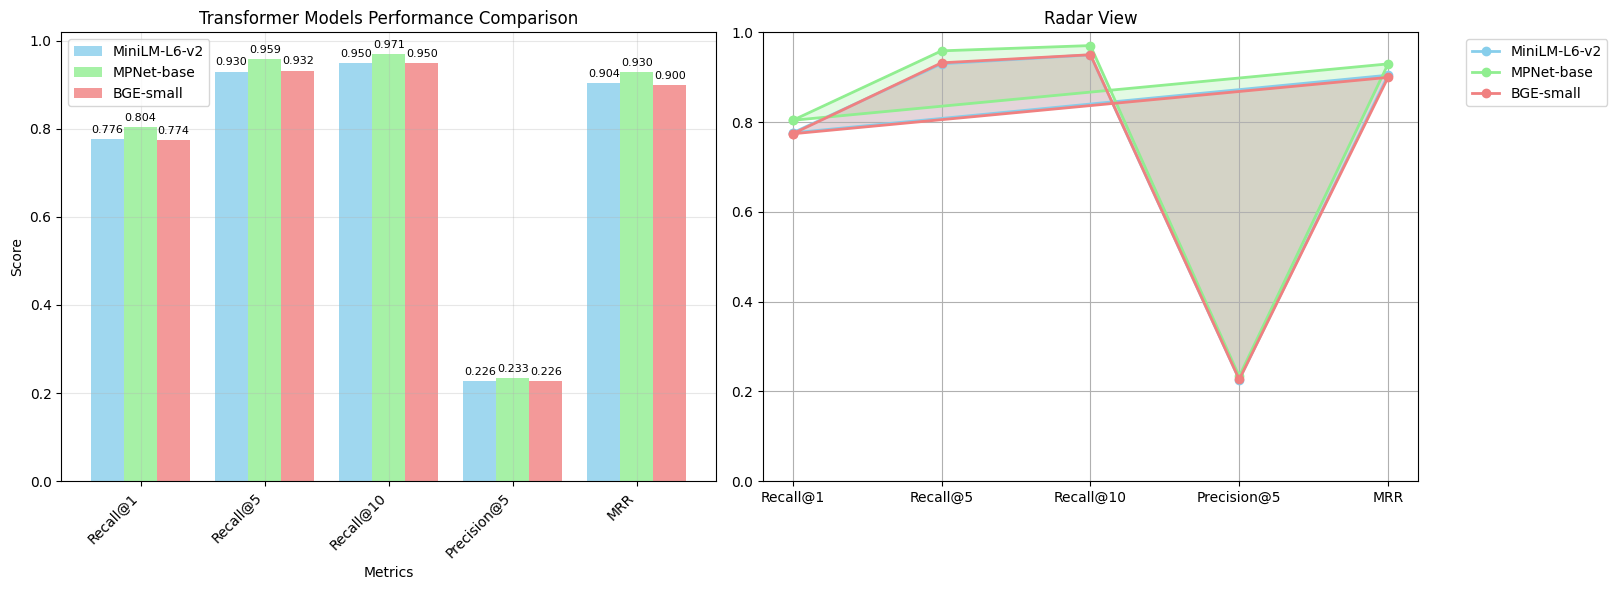


🎯 Key Performance Insights:
   🥇 Recall@1: MPNet-base (0.8039)
   🥇 Recall@5: MPNet-base (0.9587)
   🥇 Recall@10: MPNet-base (0.9705)
   🥇 Precision@5: MPNet-base (0.2333)
   🥇 MRR: MPNet-base (0.9297)

🏆 Overall Best: MPNet-base (Average Score: 0.7792)


In [11]:
print("📊 Transformer Model Comparison Analysis")
print("=" * 70)

# Create comprehensive comparison using utility functions
if len(transformer_metrics_dict) >= 2:
    # Print detailed comparison table
    print_comparison_table(transformer_metrics_dict, title="Transformer Models Performance")
    
    # Create visualization
    create_comparison_visualization(
        transformer_metrics_dict,
        title="Transformer Models Performance Comparison", 
        figsize=(16, 6),
        show_values=True,
        show_radar=True
    )
    
    # Performance insights
    print("\n🎯 Key Performance Insights:")
    model_names = list(transformer_metrics_dict.keys())
    metrics_to_compare = ['Recall@1', 'Recall@5', 'Recall@10', 'Precision@5', 'MRR']
    
    # Find best performing model for each metric
    for metric in metrics_to_compare:
        if all(metric in transformer_metrics_dict[name] for name in model_names):
            best_model = max(model_names, key=lambda x: transformer_metrics_dict[x][metric])
            best_score = transformer_metrics_dict[best_model][metric]
            print(f"   🥇 {metric}: {best_model} ({best_score:.4f})")
    
    # Overall winner
    overall_scores = {}
    for model_name in model_names:
        avg_score = np.mean([transformer_metrics_dict[model_name][metric] 
                           for metric in metrics_to_compare 
                           if metric in transformer_metrics_dict[model_name]])
        overall_scores[model_name] = avg_score
    
    if overall_scores:
        overall_winner = max(overall_scores.keys(), key=lambda x: overall_scores[x])
        print(f"\n🏆 Overall Best: {overall_winner} (Average Score: {overall_scores[overall_winner]:.4f})")
